# Байесовский подход в анализе данных
## Задание 6

**Правила:**

* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Выполненную работу нужно отправить телеграм-боту. Для начала работы с ботом каждый раз отправляйте `/start`. Дождитесь подтверждения от бота, что он принял файл. Если подтверждения нет, то что-то не так. **Работы, присланные иным способом, не принимаются.**
* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания все участники списывания получат штраф.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Для выполнения задания используйте этот ноутбук в качестве основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* В каждой задаче не забывайте делать **пояснения и выводы**.
* **Код из рассказанных на занятиях ноутбуков** можно использовать без ограничений.


**Правила оформления теоретических задач:**

* Решения необходимо прислать в виде $LaTeX$ в markdown-ячейках.
* В решениях поясняйте, чем вы пользуетесь, хотя бы кратко. Например, если пользуетесь независимостью, то достаточно подписи вида "*X и Y незав.*"
* Решение, в котором есть только ответ, и отсутствуют вычисления, оценивается в 0 баллов.



**Баллы за задание:**
* Задача 1 &mdash; 30 баллов;
* Задача 2 &mdash; 80 баллов;
* Задача 3 &mdash; 90 баллов.


In [1]:
# Bot check

# HW_ID: ds_bayes6
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(font_scale=1.2, palette='Set2')
from sklearn.decomposition import PCA

import numpy as np
import scipy.stats as sps
import matplotlib.pyplot as plt
import pandas as pd
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
import statsmodels.api as sm
import scipy.special as sp
from tqdm.auto import tqdm
from scipy.optimize import minimize
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import torch
import pyro
from torch.distributions import constraints
from pyro.optim import Adam
from pyro.infer import SVI, Trace_ELBO, TraceGraph_ELBO, config_enumerate
from IPython.display import clear_output
from matplotlib.gridspec import GridSpec
import pyro.distributions as pyro_dist

pyro.enable_validation(True)

plt.rcParams.update({
    "axes.facecolor": "#f0f0f0",
    "figure.facecolor": "#e5e5e5",
    "grid.color": "white",
    "grid.linestyle": "-",         
    "grid.alpha": 0.7,
    "axes.edgecolor": "gray",
    "axes.grid": True
})

### Ссылки на чат с ИИ

Если при решении задач использовался ИИ, укажите здесь ссылки на чаты с ним.

**Задача 1**
1. ...
2. ...

**Задача 2**
1. ...
2. ...

**Задача 3**
1. ...
2. ...


---

### Задача 1.

Рассмотрим модель 

* выборка $(X_1, ..., X_n)\:|\:\theta \sim \mathcal{N}(\theta_1, \theta_2^{-1})$;

* параметры $\theta = (\theta_1, \theta_2)$ имеют априорное гамма-нормальное распределение.

Распределения в вариационном семействе $\mathcal{Q}$ факторизуются на независимые нормальные и гамма распределения.

Реализуйте стохастический вариационный вывод с помощью Pyro. Сравните с реализацией вариационного вывода из занятия 2.

In [3]:
def callback(trace, it, figsize=(10, 10)):
    """
    Отрисовка текущего статуса обучения.
    * pi -- оценки вероятностей кластеров на текущей итерации
    * theta -- вероятности белых пикселей на текущей итерации
    * elbo_trace -- зависимость логарифма вариационной нижней оценки от номера итерации
        до текущей итерации включительно
    * optim_elbo -- оптимальная ELBO за все время обучения
    * init -- номер инициализации параметров
    * it -- номер итерации обучения

    Обратите внимание, что использование данной функции может замедлять скорость обучения.
    """

    # Отложенная очистка экрана
    clear_output(wait=True)

    # Объявление фигуры и сетки
    fig = plt.figure(figsize=figsize, constrained_layout=True)
    plt.suptitle(f"Итерация {it}")
    gs = GridSpec(4, 2, figure=fig)

    # График вероятностей кластеров
    for i, label in enumerate(trace.keys()):
        if i == 0:
            ax = fig.add_subplot(gs[0, :])
        else:
            ax = fig.add_subplot(gs[(i + 1) // 2, (i + 1) % 2])
        ax.plot(trace[label], lw=2, color="#00CC66")
        ax.set_xlabel("Номер итерации")
        ax.set_title(label)
    sns.set_style("darkgrid")

    plt.tight_layout()
    plt.show()


def visualize_or_not(it, n_iter):
    """
    Функция, которая определяет, визуализировать ли результат данной итерации.

    * it -- номер текущей итерации
    * n_iter -- количество итераций чередования E и M шагов
    """

    return (
        (it < 10)
        or ((it % 10 == 0) and (it < 100))
        or ((it % 100 == 0) and (it < 1000))
        or (it % 1000 == 0)
    )

In [4]:
class GammaNormal:
    def __init__(self, data, mu=0, sigma=1, alpha=1, beta=1):
        pyro.clear_param_store()
        self.data = torch.tensor(data, dtype=torch.float32)
        self.mu_prior = torch.tensor(mu, dtype=torch.float32)
        self.sigma_prior = torch.tensor(sigma, dtype=torch.float32)
        self.alpha_prior = torch.tensor(alpha, dtype=torch.float32)
        self.beta_prior = torch.tensor(beta, dtype=torch.float32)

    def model(self):
        theta1 = pyro.sample(
            "theta1", pyro_dist.Normal(self.mu_prior, self.sigma_prior)
        )
        theta2 = pyro.sample(
            "theta2",
            pyro_dist.Gamma(self.alpha_prior, self.beta_prior)
        )
        for i in range(self.data.shape[0]):
            pyro.sample(
                f"obs_{i}",
                pyro_dist.Normal(theta1, 1.0 / torch.sqrt(theta2)),
                obs=self.data[i],
            )

    def guide(self):
        alpha = pyro.param("alpha", self.alpha_prior, constraint=constraints.positive)
        beta = pyro.param("beta", self.beta_prior, constraint=constraints.positive)
        mu = pyro.param("mu", self.mu_prior)
        sigma = pyro.param(
            "sigma", self.sigma_prior, constraint=constraints.positive
        )

        pyro.sample("theta1", pyro_dist.Normal(mu, sigma))
        pyro.sample("theta2", pyro_dist.Gamma(alpha, beta))

    def fit(self, num_steps=1000, lr=0.01):
        optimizer = Adam({"lr": lr})
        svi = SVI(self.model, self.guide, optimizer, loss=Trace_ELBO())

        pyro.clear_param_store()
        losses = []
        trace = {"ELBO": [], "mu": [], "sigma": [], "alpha": [], "beta": []}

        for step in range(num_steps):
            loss = svi.step()
            losses.append(loss)
            trace["ELBO"].append(-loss)  # сохраняем ELBO (по определению отрицательный loss)

            # Сохраняем параметры
            for name in ["mu", "sigma", "alpha", "beta"]:
                if name in pyro.get_param_store():
                    trace[name].append(pyro.param(name).item())

            # Визуализация
            if visualize_or_not(step, num_steps):
                callback(trace, step)

        self.losses = losses
        self.trace = trace
        return losses
    
    def get_params(self):
        """Возвращает текущие обученные параметры вариационного распределения."""
        return {
            "mu": pyro.param("mu").item(),
            "sigma": pyro.param("sigma").item(),
            "alpha": pyro.param("alpha").item(),
            "beta": pyro.param("beta").item(),
        }

In [5]:

# Данные
n_train = 30
theta_1_true = 5
theta_2_true = 4
sigma_true = 1 / np.sqrt(theta_2_true)

X_train = np.random.normal(theta_1_true, sigma_true, size=n_train)
X_bar = X_train.mean()
sum_sq = np.sum((X_train - X_bar)**2)

# Априорные параметры
mu_0 = 0
lambda_0 = 1
alpha_0 = 1
beta_0 = 1

n = len(X_train)
X_bar = X_train.mean()
sum_sq_dev = np.sum((X_train - X_bar)**2)
mu_n = (lambda_0 * mu_0 + n * X_bar) / (lambda_0 + n)
lambda_n = lambda_0 + n
sigma_n = np.sqrt(1 / lambda_n)

alpha_n = alpha_0 + n / 2
beta_n = (beta_0 
          + 0.5 * sum_sq_dev 
          + 0.5 * (lambda_0 * n * (X_bar - mu_0)**2) / (lambda_0 + n))

print("Апостериорные параметры:")
print(f"mu    = {mu_n:.4f}")
print(f"sigma = {sigma_n:.4f}")
print(f"alpha = {alpha_n:.4f}")
print(f"beta  = {beta_n:.4f}")


Апостериорные параметры:
mu    = 4.9156
sigma = 0.1796
alpha = 16.0000
beta  = 16.6561


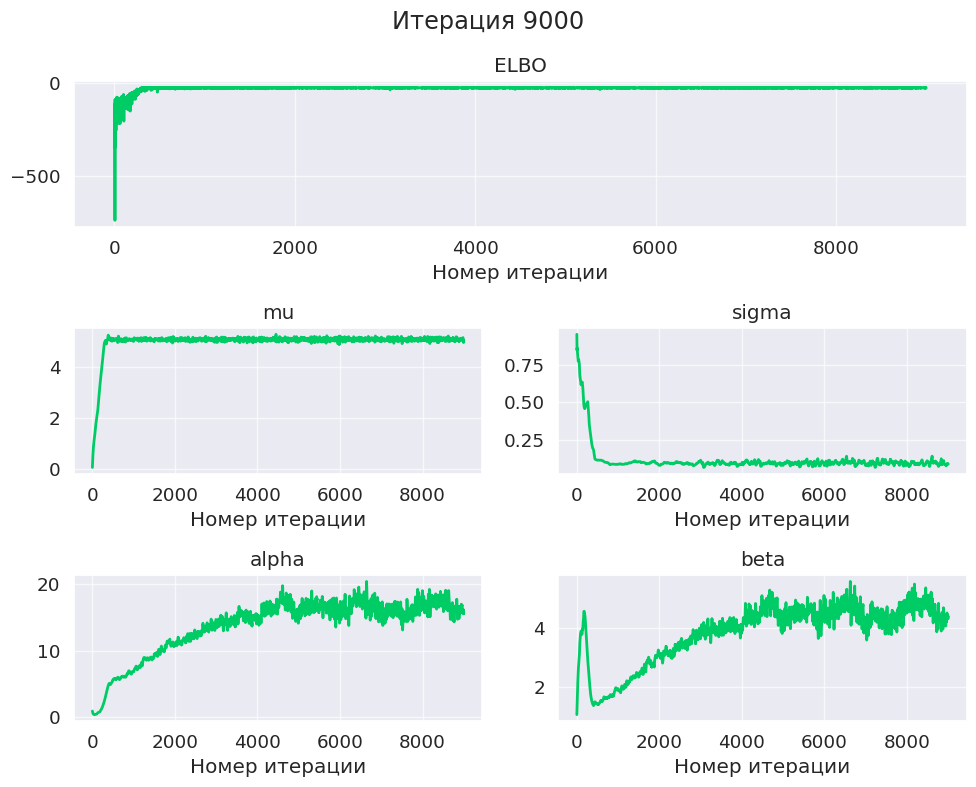

In [6]:
model = GammaNormal(X_train)
model.fit(num_steps=10000, lr=0.05);

In [7]:
model.get_params()

{'mu': 5.043666839599609,
 'sigma': 0.09862571954727173,
 'alpha': 13.927706718444824,
 'beta': 5.457599639892578}

Мы получили неплохую оценку параметров модели.

Причем, нам не пришлось честно выписывать формулу ELBO, как это было во 2-м задании, что значительно ускорило вывод.

Измените код, используя `pyro.plate`, сравните процесс обучения и результаты.

In [8]:
class GammaNormalPlate(GammaNormal):
    def __init__(self, data, subsample_size=None):
        super().__init__(data)
        self.subsample_size = subsample_size

    def model(self):
        theta1 = pyro.sample("theta1", pyro_dist.Normal(self.mu_prior, self.sigma_prior))
        theta2 = pyro.sample("theta2", pyro_dist.Gamma(self.alpha_prior, self.beta_prior))

        with pyro.plate("observe_data", size=self.data.shape[0], subsample_size=self.subsample_size) as ind:
            pyro.sample(
                "obs",
                pyro_dist.Normal(theta1, 1.0 / torch.sqrt(theta2)),
                obs=self.data.index_select(0, ind),
            )

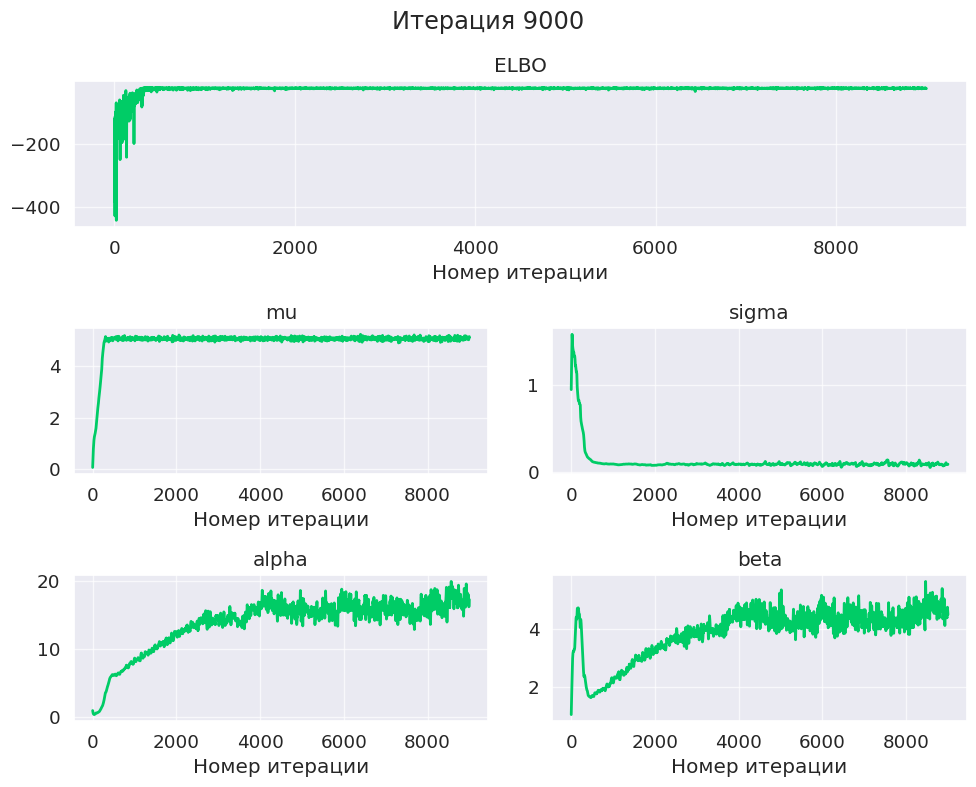

In [9]:
model = GammaNormalPlate(X_train)
model.fit(num_steps=10000, lr=0.05);

In [10]:
model.get_params()

{'mu': 5.111037731170654,
 'sigma': 0.10418763011693954,
 'alpha': 16.82357406616211,
 'beta': 3.9569814205169678}

Все параметры почти совпали, кроме $\beta$. Время на обучение уменьшилось больше чем в два раза.

Измените код, применив субсэмплинг, сравните процесс обучения и результаты.

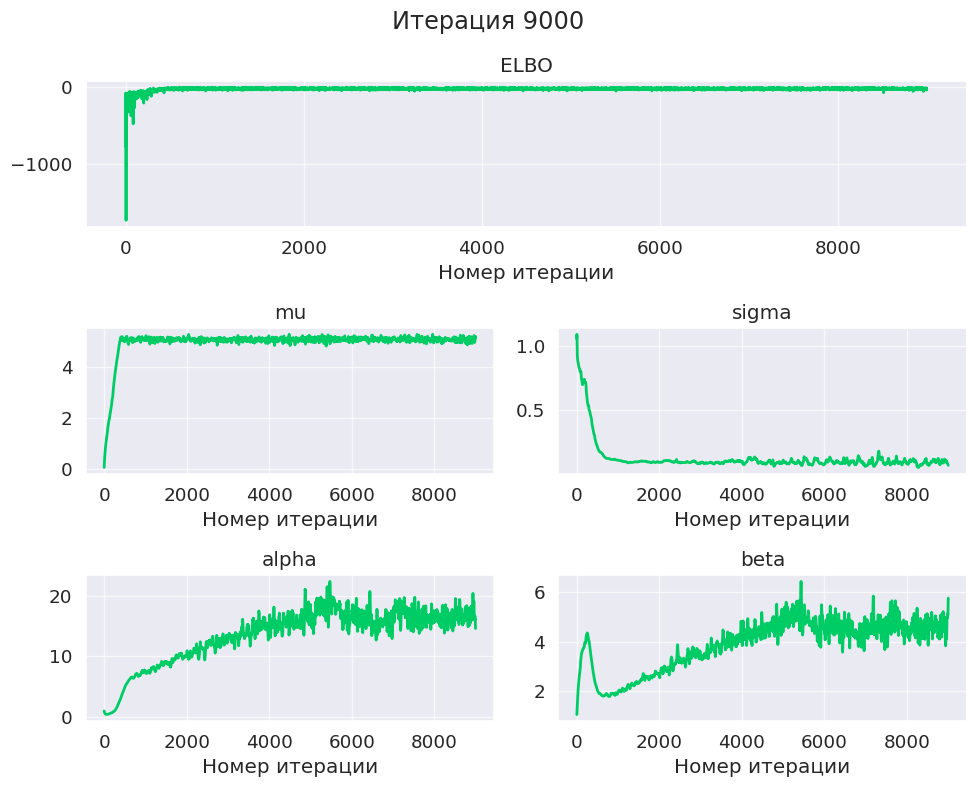

In [11]:
model = GammaNormalPlate(X_train, 5)
model.fit(num_steps=10000, lr=0.05);

In [12]:
model.get_params()

{'mu': 5.116786003112793,
 'sigma': 0.08092603087425232,
 'alpha': 15.505250930786133,
 'beta': 4.686252117156982}

Результат почти такой же, что и без субсэмплинга. Лишь параметры были угаданы менее точно.

Возьмите модель из предыдущего пункта и попробуйте использовать нерепараметризованное гамма-нормальное распределение при помощи `pyro.distributions.testing.fakes.NonreparameterizedGamma`. Как это повлияло на скорость сходимости и итоговые значения параметров?

In [13]:
class NonreparameterizedGamma(GammaNormal):
    def __init__(self, data, subsample_size=None):
        super().__init__(data)
        self.subsample_size = subsample_size

    def model(self):
        theta1 = pyro.sample("theta1", pyro_dist.Normal(self.mu_prior, self.sigma_prior))
        theta2 = pyro.sample("theta2", pyro_dist.testing.fakes.NonreparameterizedGamma(self.alpha_prior, self.beta_prior))

        with pyro.plate("observe_data", size=self.data.shape[0], subsample_size=self.subsample_size) as ind:
            pyro.sample(
                "obs",
                pyro_dist.Normal(theta1, 1.0 / torch.sqrt(theta2)),
                obs=self.data.index_select(0, ind),
            )
    
    def guide(self):
        alpha = pyro.param("alpha", self.alpha_prior, constraint=constraints.positive)
        beta = pyro.param("beta", self.beta_prior, constraint=constraints.positive)
        mu = pyro.param("mu", self.mu_prior)
        sigma = pyro.param(
            "sigma", self.sigma_prior, constraint=constraints.positive
        )

        pyro.sample("theta1", pyro_dist.Normal(mu, sigma))
        pyro.sample("theta2", pyro_dist.testing.fakes.NonreparameterizedGamma(alpha, beta))

    def fit(self, num_steps=1000, lr=0.01):
        optimizer = Adam({"lr": lr})
        svi = SVI(self.model, self.guide, optimizer, loss=TraceGraph_ELBO())

        pyro.clear_param_store()
        losses = []
        trace = {"ELBO": [], "mu": [], "sigma": [], "alpha": [], "beta": []}

        for step in range(num_steps):
            loss = svi.step()
            losses.append(loss)
            trace["ELBO"].append(-loss)  # сохраняем ELBO (по определению отрицательный loss)

            # Сохраняем параметры
            for name in ["mu", "sigma", "alpha", "beta"]:
                if name in pyro.get_param_store():
                    trace[name].append(pyro.param(name).item())

            # Визуализация
            if visualize_or_not(step, num_steps):
                callback(trace, step)

        self.losses = losses
        self.trace = trace
        return losses

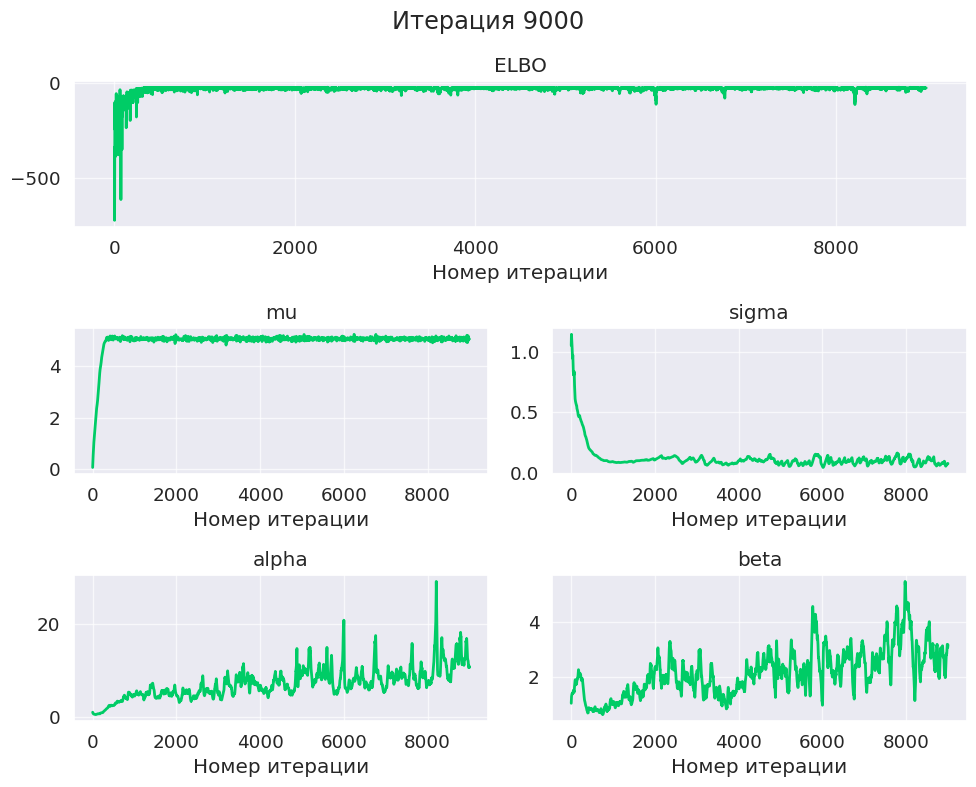

In [14]:
model = NonreparameterizedGamma(X_train)
model.fit(num_steps=10000, lr=0.05);

In [15]:
model.get_params()

{'mu': 5.1187310218811035,
 'sigma': 0.1578243225812912,
 'alpha': 8.835222244262695,
 'beta': 8.275446891784668}

Оценки параметров стали очень шумными, а время работы увеличилось.

Добавьте использование бейзлайнов при использовании нерепараметризованное гамма-нормальное распределения и сравните результаты с предыдущими случаями.

In [16]:
class BaselineInfer(GammaNormal):
    def __init__(self, data):
        super().__init__(data)

    def model(self):
        theta1 = pyro.sample(
            "theta1", pyro_dist.Normal(self.mu_prior, self.sigma_prior)
        )
        theta2 = pyro.sample(
            "theta2",
            pyro_dist.testing.fakes.NonreparameterizedGamma(self.alpha_prior, self.beta_prior)
        )

        with pyro.plate("observe_data"):
            pyro.sample(
                "obs",
                pyro_dist.Normal(theta1, 1.0 / torch.sqrt(theta2)),
                obs=self.data,
            )
    

    def guide(self):
        alpha = pyro.param("alpha", self.alpha_prior, constraint=constraints.positive)
        beta = pyro.param("beta", self.beta_prior, constraint=constraints.positive)
        mu = pyro.param("mu", self.mu_prior)
        sigma = pyro.param(
            "sigma", self.sigma_prior, constraint=constraints.positive
        )
        
        baseline={'use_decaying_avg_baseline': True,
                         'baseline_beta': 0.95}

        pyro.sample("theta1", pyro_dist.Normal(mu, sigma))
        pyro.sample("theta2", pyro_dist.testing.fakes.NonreparameterizedGamma(alpha, beta), infer=dict(baseline=baseline))

    def fit(self, num_steps=1000, lr=0.01):
        optimizer = Adam({"lr": lr})
        svi = SVI(self.model, self.guide, optimizer, loss=TraceGraph_ELBO())

        pyro.clear_param_store()
        losses = []
        trace = {"ELBO": [], "mu": [], "sigma": [], "alpha": [], "beta": []}

        for step in range(num_steps):
            loss = svi.step()
            losses.append(loss)
            trace["ELBO"].append(-loss)  # сохраняем ELBO (по определению отрицательный loss)

            # Сохраняем параметры
            for name in ["mu", "sigma", "alpha", "beta"]:
                if name in pyro.get_param_store():
                    trace[name].append(pyro.param(name).item())

            # Визуализация
            if visualize_or_not(step, num_steps):
                callback(trace, step)

        self.losses = losses
        self.trace = trace
        return losses


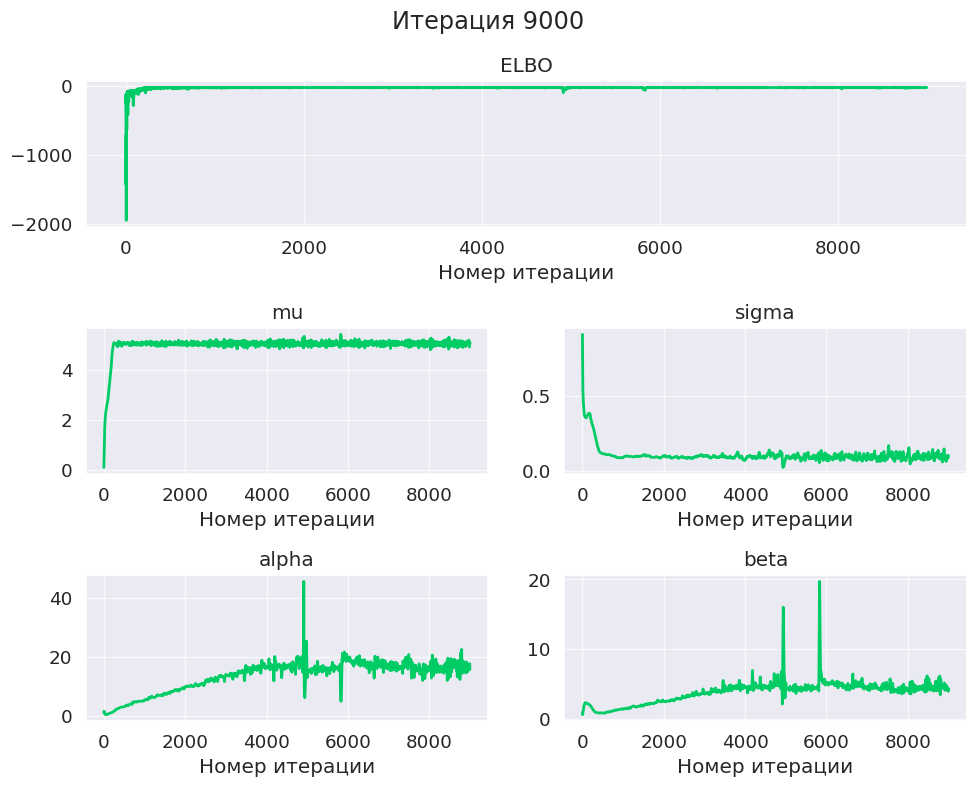

In [17]:
model = BaselineInfer(X_train)
model.fit(num_steps=10000, lr=0.1);

In [18]:
model.get_params()

{'mu': 5.088981628417969,
 'sigma': 0.1140277162194252,
 'alpha': 22.39480972290039,
 'beta': 5.893468379974365}

Благодаря baseline мы смогли уменьшить шумность оценок. 

Причем результат сопоставим со случаем, когда репараметризация есть.

**Выводы:**

Мы рассмотрели различным способы рабты с библиотекой Pyro. Хочется отметить, что исползование plate в векторизованном виде значительно ускорило работу.

Все методы неплохо оценили мат. ождание и стандартное отклонение, а также $\alpha$, но ни один не смог оценить $\beta$.


Также мы потвердили, что использование baseline действиетельно понижает дисперсию в случае отсутствея репараметризации.

---

### Задача 2.

Реализуйте с помощью Pyro вероятностную модель метода главных компонент. При реализации не забудьте:
* прописать все условные связи зависимости и независимости, используя `pyro.plate` и разделение размерности распределений на `batch_shape` и `event_shape`;
* ограничения на значения параметров с помощью `pyro.distributions import constraints`.

*Замечания.*
1. Обратите внимание, что в формулах на лекции на каждом шаге все латентные величины имеют одну и ту же матрицу ковариаций. Это можно использовать для упрощения модели.
2. Матрица ковариаций должна быть неотрицательно определенной. Для этого можно воспользоваться <a href="https://github.com/pytorch/pytorch/blob/e0e15a4ac61648cc8f63f0ab102c32e8884fb5d1/torch/distributions/constraints.py#L23">специальным ограничением</a>. Также можно вместо нее подбирать другую матрицу $A$, из которой получать матрицу ковариаций как $AA^T$.

In [19]:
class StochasticPCA:
    def __init__(self, data, n_classes):
        data = torch.tensor(data, dtype=torch.float32)
        self.data = data
        self.n, self.D = data.shape
        self.d = n_classes

        self.mu_prior = torch.mean(self.data, dim=0)
        self.W_prior = torch.randn(self.D, self.d)
        self.sigma = torch.tensor(1.0)

    def model(self):
        W = pyro.param("W", self.W_prior)
        mu = pyro.param("mu", self.mu_prior)
        sigma = pyro.param("sigma", self.sigma)

        with pyro.plate("data", self.n):

            Y = pyro.sample("Y", pyro_dist.MultivariateNormal(torch.zeros(self.d), torch.eye(self.d)))
            X_mean = mu + Y @ W.T

            pyro.sample(
                "X",
                pyro_dist.MultivariateNormal(
                    X_mean,
                    sigma**2 * torch.eye(self.D),
                ),
                obs=self.data,
            )

    def guide(self):
        Y_loc = pyro.param("Y_loc", torch.randn(self.n, self.d))
        Y_cov = pyro.param(
            "Y_cov", torch.eye(self.d), constraint=constraints.positive_definite
        )

        with pyro.plate("data", self.n):
            pyro.sample("Y", pyro_dist.MultivariateNormal(Y_loc, covariance_matrix=Y_cov))
    
    def fit(self, num_steps=1000, lr=0.01):
        pyro.clear_param_store()
        optimizer = Adam({"lr": lr})
        svi = SVI(self.model, self.guide, optimizer, loss=Trace_ELBO())
        
        elbo_mod = Trace_ELBO()(self.model, self.guide)
        elbo_mod()

        losses = []
        trace = {
            "ELBO": [],
            "W": [],  # можно логировать норму W
            "sigma": [],
            "mu": [],  # например, норму mu
        }

        for step in range(num_steps):
            loss = svi.step()
            losses.append(loss)
            trace["ELBO"].append(-loss)  # ELBO = -loss

            # Логируем ключевые параметры
            if "sigma" in pyro.get_param_store():
                trace["sigma"].append(pyro.param("sigma").item())
            if "W" in pyro.get_param_store():
                trace["W"].append(pyro.param("W").norm().item())
            if "mu" in pyro.get_param_store():
                trace["mu"].append(pyro.param("mu").norm().item())

            # Визуализация (опционально)
            if visualize_or_not(step, num_steps):
                callback(trace, step)

        self.losses = losses
        self.trace = trace
        return losses

    def get_params(self):
        """Возвращает обученные параметры модели и guide."""
        return {
            "W": pyro.param("W").detach().clone(),
            "mu": pyro.param("mu").detach().clone(),
            "sigma": pyro.param("sigma").item(),
            "Y_loc": pyro.param("Y_loc").detach().clone(),
            "Y_cov": pyro.param("Y_cov").detach().clone(),
        }

Сгенерируйте выборку из двумерного нормального распределения с произвольными нетривиальными параметрами и достаточно большой корреляцией компонент. Примените реализованную модель метода главных компонент к такой выборке для сжатия в пространство размерности 1.

In [20]:
np.random.seed(42)
torch.manual_seed(42)

mu = torch.tensor([2.0, -1.0])
Sigma = torch.tensor([[4.0, 3.5],
                      [3.5, 4.0]])

train_dist = torch.distributions.MultivariateNormal(mu, covariance_matrix=Sigma)
train_data = train_dist.sample((50,))

In [21]:
mu_true = np.array([2.0, -1.0])
Sigma_true = np.array([[4.0, 3.5],
                       [3.5, 4.0]])

eigvals, eigvecs = np.linalg.eigh(Sigma_true)
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

lambda1, lambda2 = eigvals[0], eigvals[1]
u1 = eigvecs[:, 0]

sigma_true = np.sqrt(lambda2)
W_true = (u1 * np.sqrt(lambda1 - lambda2)).reshape(-1, 1)

# Вывод
print("=== Истинные параметры PPCA (аналитическое решение) ===")
print(f"mu (среднее): {mu_true}")
print(f"sigma (шум): {sigma_true:.6f}")
print(f"W (матрица весов):\n{W_true}")
print(f"\nДополнительно:")
print(f"Собственные значения ковариации: {eigvals}")
print(f"Первый главный вектор (u1): {u1}")
print(f"Корреляция в данных: {3.5 / 4.0:.3f}")

=== Истинные параметры PPCA (аналитическое решение) ===
mu (среднее): [ 2. -1.]
sigma (шум): 0.707107
W (матрица весов):
[[1.87082869]
 [1.87082869]]

Дополнительно:
Собственные значения ковариации: [7.5 0.5]
Первый главный вектор (u1): [0.70710678 0.70710678]
Корреляция в данных: 0.875


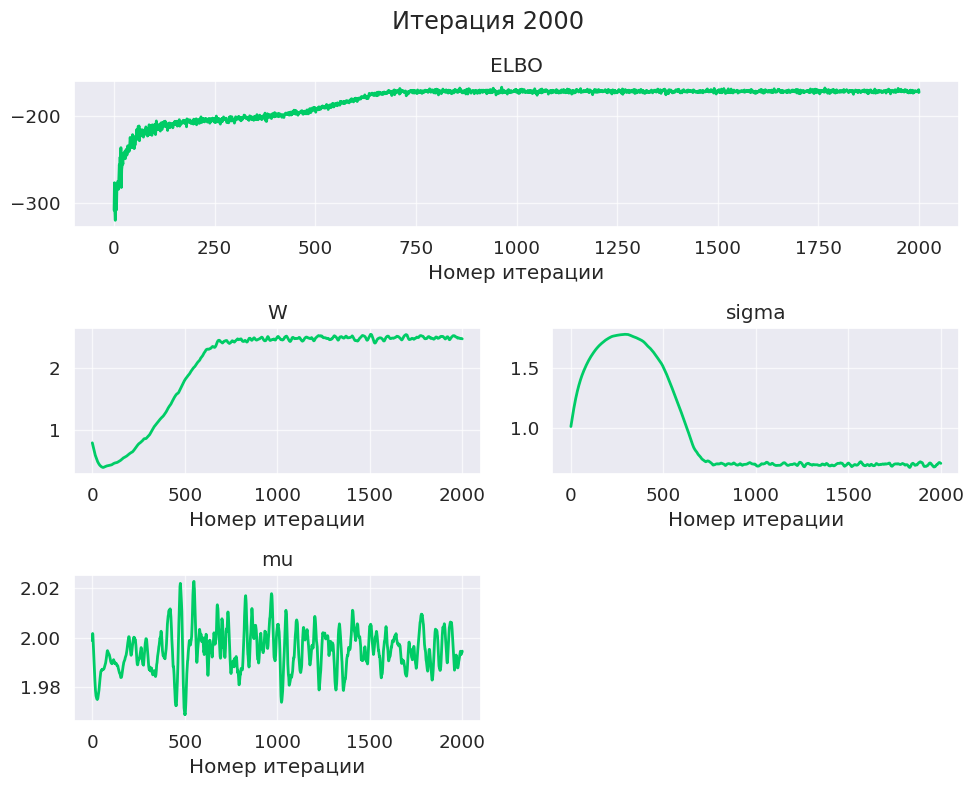

In [22]:
stochastic_pca = StochasticPCA(train_data, n_classes=1)
stochastic_pca.fit(num_steps=2001, lr=0.01)
params = stochastic_pca.get_params()

In [23]:
params = stochastic_pca.get_params()
print("\n=== Результаты StochasticPCA ===")
print(f"mu: {params['mu'].numpy()}")
print(f"sigma: {params['sigma']:.6f}")
print(f"W:\n{params['W'].numpy()}")


=== Результаты StochasticPCA ===
mu: [ 1.7313691  -0.99034905]
sigma: 0.702250
W:
[[-1.7235553]
 [-1.7809376]]


Как видим, мы почти сошлись. Найденные результаты вполне достойны.

Посчитайте и визуализируйте получаемую проекцию на одномерное пространство двумя способами:
1. Возьмите латентные величины, полученные во время вариационного вывода, например, при помощи `pyro.param('latent_loc')`. Для отображения на плоскости переведите полученные одномерные данные в двумерные при помощи формулы для классического PCA.
2. Аналогично, но значения латентных величин должны быть получены в рамках классического PCA.

1)

In [24]:
Y_loc = pyro.param('Y_loc').detach().numpy()
Y_scale = pyro.param('Y_cov').detach().numpy()

W = params["W"].detach().numpy()
mu = params["mu"].detach().numpy()
sigma = params["sigma"]

In [25]:
n, D = Y_loc.shape[0], W.shape[0]
X_on_latent_axis = mu + Y_loc @ W.T  

2)

In [26]:
X = train_data

pca = PCA(n_components=1)
pca.fit(X)

W_pca = pca.components_[0]
mu_pca = pca.mean_

Y_pca = (X - mu_pca) @ W_pca
X_on_pca_axis = mu_pca + np.outer(Y_pca, W_pca)

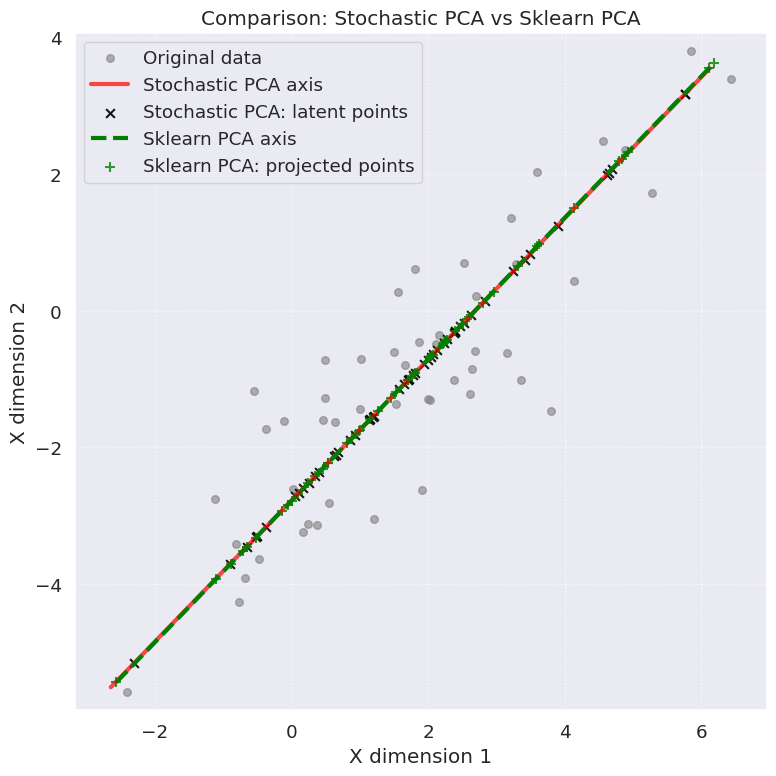

In [27]:
plt.figure(figsize=(8, 8))

# Исходные данные
plt.scatter(X[:, 0], X[:, 1], alpha=0.6, c="gray", label="Original data", s=30)

# Латентная ось Stochastic PCA
W_dir = W[:, 0] / np.linalg.norm(W[:, 0])
projections_stoch = (X - mu) @ W_dir
min_proj_s, max_proj_s = np.quantile(projections_stoch, [0.15, 0.85])
start_s = mu + min_proj_s * W[:, 0]
end_s = mu + max_proj_s * W[:, 0]
plt.plot(
    [start_s[0], end_s[0]],
    [start_s[1], end_s[1]],
    c="red",
    lw=3,
    alpha=0.7,
    label="Stochastic PCA axis",
)

# Точки на оси Stochastic PCA (без шума, контрастный цвет)
plt.scatter(
    X_on_latent_axis[:, 0],
    X_on_latent_axis[:, 1],
    c="black",
    marker="x",
    s=40,
    alpha=0.9,
    label="Stochastic PCA: latent points",
)

# Ось классической PCA
projections_pca = (X - mu_pca) @ W_pca
min_proj_p, max_proj_p = np.quantile(projections_pca, [0, 1])
start_p = mu_pca + min_proj_p * W_pca
end_p = mu_pca + max_proj_p * W_pca
plt.plot(
    [start_p[0], end_p[0]],
    [start_p[1], end_p[1]],
    c="green",
    lw=3,
    linestyle="--",
    label="Sklearn PCA axis",
)

# Точки на оси PCA
plt.scatter(
    X_on_pca_axis[:, 0],
    X_on_pca_axis[:, 1],
    c="green",
    marker="+",
    s=50,
    alpha=0.8,
    label="Sklearn PCA: projected points",
)

# Оформление
plt.xlabel("X dimension 1")
plt.ylabel("X dimension 2")
plt.title("Comparison: Stochastic PCA vs Sklearn PCA")
plt.grid(True, linestyle=":", alpha=0.7)
plt.axis("equal")
plt.legend()
plt.tight_layout()
plt.show()

Есть ли разница в результатах, получаемыми разными методами? Почему так происходит?

Как видим, прямы наложились точь в точь. Это говорит о том, что мы обучили нашу модель очень хорошо, что уже было по почти полностью совпашим апостериорным параметрам.

Это происходит, потому что наш стохастический PCA нашел то же направление, что и классический PCA.


**Выводы:**

Стохастический PCA показал себя очень хорошо, параметры были угаданы с высокой точностью, а главное направление совпало.

Причем реализация такого метода не потребовала больших усилий, что опять же говорит в пользу предложенного метода

---

### Задача 3.

**1.** Рассмотрим модель байесовской линейной регрессии, похожую на ту, которую мы ранее уже рассматривали:

$$Y = X \theta + \varepsilon,$$
где совместное распределение определяется с помощью следующих зависимостей
$$\theta \sim \mathcal{N}(0, \alpha I_d)$$
$$\varepsilon\:|\:\beta \sim \mathcal{N}(0, \beta I_n)$$
$$\beta \sim HalfCauchy()$$

Осуществите процедуру вариационного вывода в данной модели с помощью Pyro, оформив код в виде следующего класса. В качестве вариационного семейства распределений рассматривайте такое, в котором $\theta$ и $\beta$ независимы.

In [57]:
from typing import Callable

class PyroBayesianRidge:
    def __init__(
        self,
        X,
        Y,
        priors,
    ):
        """
        priors -- словарь с априорными значениями
        n_iter -- количество итераций SVI
        callback -- функция для визуализации параметров
        visualize -- условия вызова callback
        """
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)
        self.n, self.d = self.X.shape

        self.alpha_prior = torch.tensor(priors.get("alpha", 1e-3), dtype=torch.float32)
        self.beta_scale = torch.tensor(
            priors.get("beta_scale", 1e-1), dtype=torch.float32
        )

    def model(self):
        theta = pyro.sample(
            "theta",
            pyro_dist.MultivariateNormal(
                torch.zeros(self.d), torch.sqrt(self.alpha_prior) * torch.eye(self.d)
            ),
        )

        beta = pyro.sample("beta", pyro_dist.HalfCauchy(scale=self.beta_scale))

        with pyro.plate("data", self.n):
            mean = self.X @ theta
            pyro.sample("Y", pyro_dist.Normal(mean, torch.sqrt(beta)), obs=self.Y)

    def guide(self):
        theta_loc = pyro.param("theta_loc", torch.zeros(self.d))
        theta_cov = pyro.param(
            "theta_cov",
            self.alpha_prior * torch.eye(self.d),
            constraint=constraints.positive_definite,
        )
        pyro.sample("theta", pyro_dist.MultivariateNormal(theta_loc, theta_cov))

        # beta_loc = pyro.param("beta_loc", torch.tensor(13.8)) # IT'S MAGIC 
        beta_loc = pyro.param("beta_loc", torch.tensor(0.0)) # IT'S MAGIC 

        beta_scale = pyro.param("beta_scale", torch.tensor(1.0), constraint=constraints.positive)
        pyro.sample("beta", pyro_dist.LogNormal(beta_loc, beta_scale))

    def fit(self, n_iter=2000, lr=0.01):
        pyro.clear_param_store()
        optimizer = Adam({"lr": lr, "betas": (0.90, 0.999)})
        svi = SVI(self.model, self.guide, optimizer, loss=Trace_ELBO())

        losses = []
        trace = {
            "ELBO": [],
            "theta_mean": [],
            "theta_var": [],
            "beta_mean": [],
            "beta_std": [],
        }

        for step in range(n_iter):
            loss = svi.step()
            losses.append(loss)
            trace["ELBO"].append(-loss)

            # Theta
            theta_loc = pyro.param("theta_loc")
            theta_cov = pyro.param("theta_cov")
            trace["theta_mean"].append(theta_loc.detach().cpu().numpy().copy())
            trace["theta_var"].append(torch.diag(theta_cov).detach().cpu().numpy().copy())

            # Beta (LogNormal)
            beta_loc = pyro.param("beta_loc")
            beta_scale_param = pyro.param("beta_scale")

            beta_mean = torch.exp(beta_loc + 0.5 * beta_scale_param ** 2)
            beta_var = (torch.exp(beta_scale_param ** 2) - 1) * torch.exp(2 * beta_loc + beta_scale_param ** 2)
            beta_std = torch.sqrt(beta_var)

            trace["beta_mean"].append(beta_mean.item())
            trace["beta_std"].append(beta_std.item())

            if visualize_or_not(step, n_iter):
                callback(trace, step)

        self.losses = losses
        self.trace = trace
        return losses

    def predict(self, X):
        """
        Предсказания модели.
        X -- таблица признаков в виде torch.tensor
        """

        X = torch.tensor(X, dtype=torch.float32)
        theta_loc = pyro.param("theta_loc")
        beta_scale = pyro.param("beta_scale")

        return X @ theta_loc, beta_scale

    def get_params(self):
        return {
            "theta_loc": pyro.param("theta_loc").detach().clone(),
            "theta_cov": pyro.param("theta_cov").detach().clone(),
            "beta_scale": pyro.param("beta_scale").item(),
        }

Загрузите датасет `bikes_rent.csv` из задач 1.3 и 2.2 и переведите их в формат `torch.tensor`. Разделите данные на обучающую и тестовую части.

сразу сделаю предобработку, которая была в 1.3

In [58]:
# === Загрузка и предварительная очистка ===
df = pd.read_csv("/home/alexander/DS/BS_in_DA/hw1/bikes_rent.csv")

numerical_cols = ["temp", "atemp", "hum", "windspeed(mph)", "windspeed(ms)"]
categorical_cols = ["season", "yr", "mnth", "holiday", "weekday", "workingday", "weathersit"]

# фильтруем шумные значения
df = df[(df["windspeed(ms)"] < 12) & (df["hum"] > 20)]

# убираем лишние признаки
df = df.drop(columns=["windspeed(mph)", "temp", "mnth"])
numerical_cols = ["atemp", "hum", "windspeed(ms)"]
categorical_cols = ["season", "yr", "holiday", "weekday", "workingday", "weathersit"]

# === train/test split ===
train_df, test_df = train_test_split(
    df[[*numerical_cols, *categorical_cols, "cnt"]],
    test_size=0.2,
    random_state=42
)

X_train, y_train = train_df.drop("cnt", axis=1), train_df["cnt"]
X_test, y_test = test_df.drop("cnt", axis=1), test_df["cnt"]

# === нормализация числовых признаков ===
scaler_num = MinMaxScaler()
X_train_num = pd.DataFrame(
    scaler_num.fit_transform(X_train[numerical_cols]),
    columns=numerical_cols,
    index=X_train.index
)
X_test_num = pd.DataFrame(
    scaler_num.transform(X_test[numerical_cols]),
    columns=numerical_cols,
    index=X_test.index
)

# === target encoding категориальных ===
X_train_cat = pd.DataFrame(index=X_train.index)
X_test_cat = pd.DataFrame(index=X_test.index)

for col in categorical_cols:
    tmp = pd.DataFrame({col: X_train[col], 'target': y_train})
    mean_map = tmp.groupby(col)['target'].mean()

    # map к среднему
    X_train_cat[col + "_mean"] = X_train[col].map(mean_map)
    X_test_cat[col + "_mean"] = X_test[col].map(mean_map)
    X_test_cat[col + "_mean"] = X_test_cat[col + "_mean"].fillna(y_train.mean())

# --- масштабируем target encoding в [0,1] ---
scaler_cat = MinMaxScaler()
X_train_cat = pd.DataFrame(
    scaler_cat.fit_transform(X_train_cat),
    columns=X_train_cat.columns,
    index=X_train_cat.index
)
X_test_cat = pd.DataFrame(
    scaler_cat.transform(X_test_cat),
    columns=X_test_cat.columns,
    index=X_test_cat.index
)

# === объединяем числовые и категориальные признаки ===
X_train_df = pd.concat([X_train_num, X_train_cat], axis=1)
X_test_df = pd.concat([X_test_num, X_test_cat], axis=1)

# === финальные numpy-массивы ===
X_train = X_train_df.to_numpy(dtype=np.float32)
X_test = X_test_df.to_numpy(dtype=np.float32)

Y_train = y_train.to_numpy(dtype=np.float32).reshape(-1, 1)
Y_test = y_test.to_numpy(dtype=np.float32).reshape(-1, 1)

scaler_y = MinMaxScaler()
Y_train = scaler_y.fit_transform(Y_train.reshape(-1, 1))
Y_test = scaler_y.transform(Y_test.reshape(-1, 1))

# приводим к float32
Y_train = Y_train.astype(np.float32).ravel()
Y_test = Y_test.astype(np.float32).ravel()


print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Y_train: {Y_train.shape}, Y_test: {Y_test.shape}")
print(f"X_train min/max: {X_train.min():.3f}/{X_train.max():.3f}")
print(f"X_test min/max: {X_test.min():.3f}/{X_test.max():.3f}")
print(f"Y_train min/max: {Y_train.min():.3f}/{Y_train.max():.3f}")
print(f"Y_test min/max: {Y_test.min():.3f}/{Y_test.max():.3f}")

X_train: (576, 9), X_test: (145, 9)
Y_train: (576,), Y_test: (145,)
X_train min/max: 0.000/1.000
X_test min/max: -0.031/1.050
Y_train min/max: 0.000/1.000
Y_test min/max: -0.049/0.981


In [59]:
def get_metrics(y_true, y_pred, model_name="Linear Regression"):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    
    nonzero_idx = y_true != 0
    if np.any(nonzero_idx):
        mape = np.mean(np.abs((y_true[nonzero_idx] - y_pred[nonzero_idx]) / y_true[nonzero_idx])) * 100
    else:
        mape = np.nan
    
    metrics = {
        "Metric": ["MSE", "MAE", "MAPE (%)"],
        model_name: [np.round(mse, 2), np.round(mae, 2), np.round(mape, 2)]
    }
    
    return pd.DataFrame(metrics)

def plot_test_pred(y_true, y_pred, model_name="Model"):
    plt.figure(figsize=(8,6))
    plt.scatter(y_true, y_pred, alpha=0.6)
    plt.plot([y_true.min(), y_true.max()],
             [y_true.min(), y_true.max()],
             'r--', lw=2)  # линия y = x
    plt.xlabel("Истинные значения")
    plt.ylabel("Предсказанные значения")
    plt.title(f"Предсказания vs Истинные значения ({model_name})")
    plt.grid(True)
    plt.show()


Обучите написанную ранее модель. Во время обучения печатайте трассировку следующих величин:
- ELBO;
- матем. ожидание коэффициентов по вариационному распределению;
- матем. ожидание дисперсии по вариационному распределению.

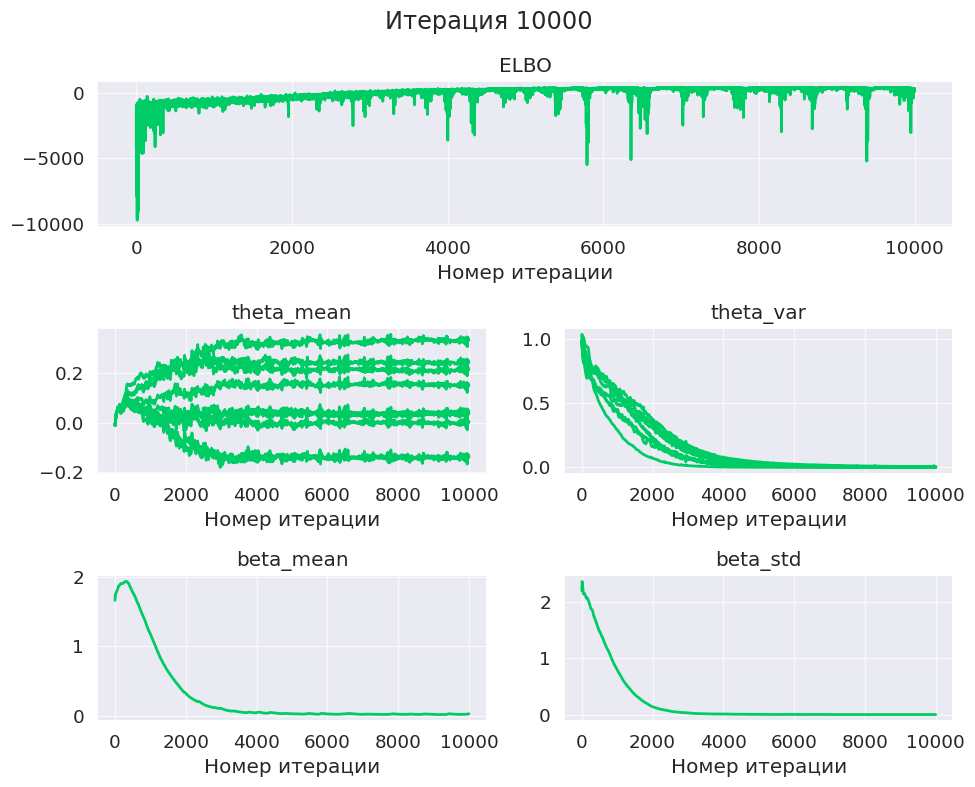

In [60]:
model = PyroBayesianRidge(X_train, Y_train, {"alpha":1, "beta_scale":0.25})
model.fit(n_iter=10001, lr=5e-3);

In [61]:
y_pred = model.predict(X_test)
y_pred = y_pred[0].detach().numpy()
y_pred = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).ravel()

In [62]:
results = get_metrics(y_test, y_pred, model_name="PyroBayesianRidge")
results

,Metric,PyroBayesianRidge
0,MSE,797492.94
1,MAE,653.39
2,MAPE (%),131.18


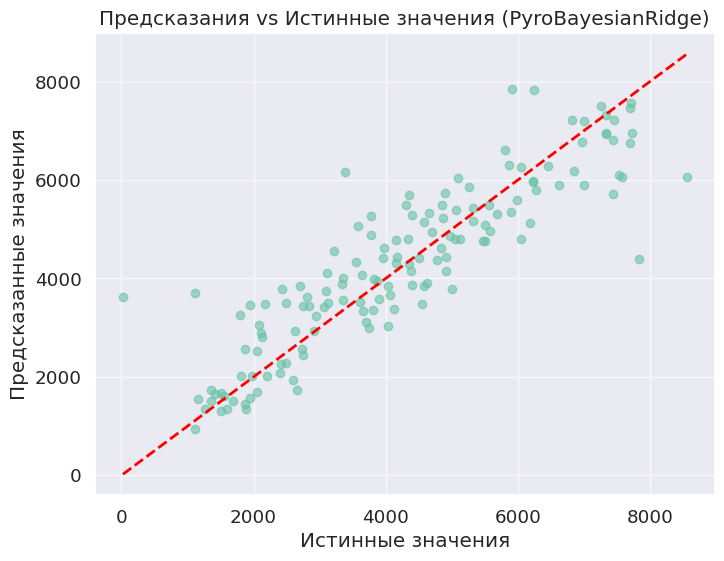

In [63]:
plot_test_pred(y_test, y_pred, "PyroBayesianRidge")

Проинтерпретируйте результаты и посчитайте качество предсказаний.

Качество посчитано выше.
Мы видим, как под конеч beta начала колебаться, что может говорить о том, что модель не может корректно оценить дисперсию.

Также сложным представляется выбор вариционного семейства для $\beta$, я выбрал LogNorm, так как оно положительно и имеет бесконечный носитель, а также репараметризуемо.


**2.** Сделайте вашу модель робастной, заменив нормальное распределение для наблюдаемых значений на распределение Стьюдента. Число степеней свободы распределения Стьюдента также можно сделать обучаемым параметром, причем как случайным, так и неслучайным. Обучите модель и сравните результат.

In [64]:
class PyroBayesianRidgeStudent(PyroBayesianRidge):
    def __init__(
        self,
        X,
        Y,
        priors,
    ):
        super().__init__(X, Y, priors)

    def guide(self):
        theta_loc = pyro.param("theta_loc", torch.zeros(self.d))
        theta_cov = pyro.param(
            "theta_cov",
            self.alpha_prior * torch.eye(self.d),
            constraint=constraints.positive_definite,
        )
        theta_df = pyro.param(
            "theta_df", torch.tensor(50.0), constraint=constraints.positive
        )

        scale_tril = torch.linalg.cholesky(theta_cov)
        pyro.sample(
            "theta",
            pyro_dist.MultivariateStudentT(
                df=theta_df, loc=theta_loc, scale_tril=scale_tril
            ),
        )

        beta_loc = pyro.param("beta_loc", torch.tensor(13.8)) # IT'S MAGIC 
        beta_scale = pyro.param("beta_scale", torch.tensor(1.0), constraint=constraints.positive)
        pyro.sample("beta", pyro_dist.LogNormal(beta_loc, beta_scale))
    def fit(self, n_iter=2000, lr=0.01):
        pyro.clear_param_store()
        optimizer = Adam({"lr": lr, "betas": (0.90, 0.999)})
        svi = SVI(self.model, self.guide, optimizer, loss=Trace_ELBO())

        losses = []
        trace = {
            "ELBO": [],
            "theta_mean": [],
            "theta_var": [],
            "theta_df": [],
            "beta_mean": [],
            "beta_std": [],
        }

        for step in range(n_iter):
            loss = svi.step()
            losses.append(loss)
            trace["ELBO"].append(-loss)

            theta_loc = pyro.param("theta_loc")
            theta_cov = pyro.param("theta_cov")
            theta_df = pyro.param("theta_df")

            trace["theta_mean"].append(theta_loc.detach().cpu().numpy().copy())
            trace["theta_var"].append(torch.diag(theta_cov).detach().cpu().numpy().copy())
            trace["theta_df"].append(theta_df.item())

            beta_loc = pyro.param("beta_loc")
            beta_scale_param = pyro.param("beta_scale")

            beta_mean = torch.exp(beta_loc + 0.5 * beta_scale_param ** 2)
            beta_var = (torch.exp(beta_scale_param ** 2) - 1) * torch.exp(2 * beta_loc + beta_scale_param ** 2)
            beta_std = torch.sqrt(beta_var)

            trace["beta_mean"].append(beta_mean.item())
            trace["beta_std"].append(beta_std.item())

            if visualize_or_not(step, n_iter):
                callback(trace, step, (10, 14))

        self.losses = losses
        self.trace = trace
        return losses

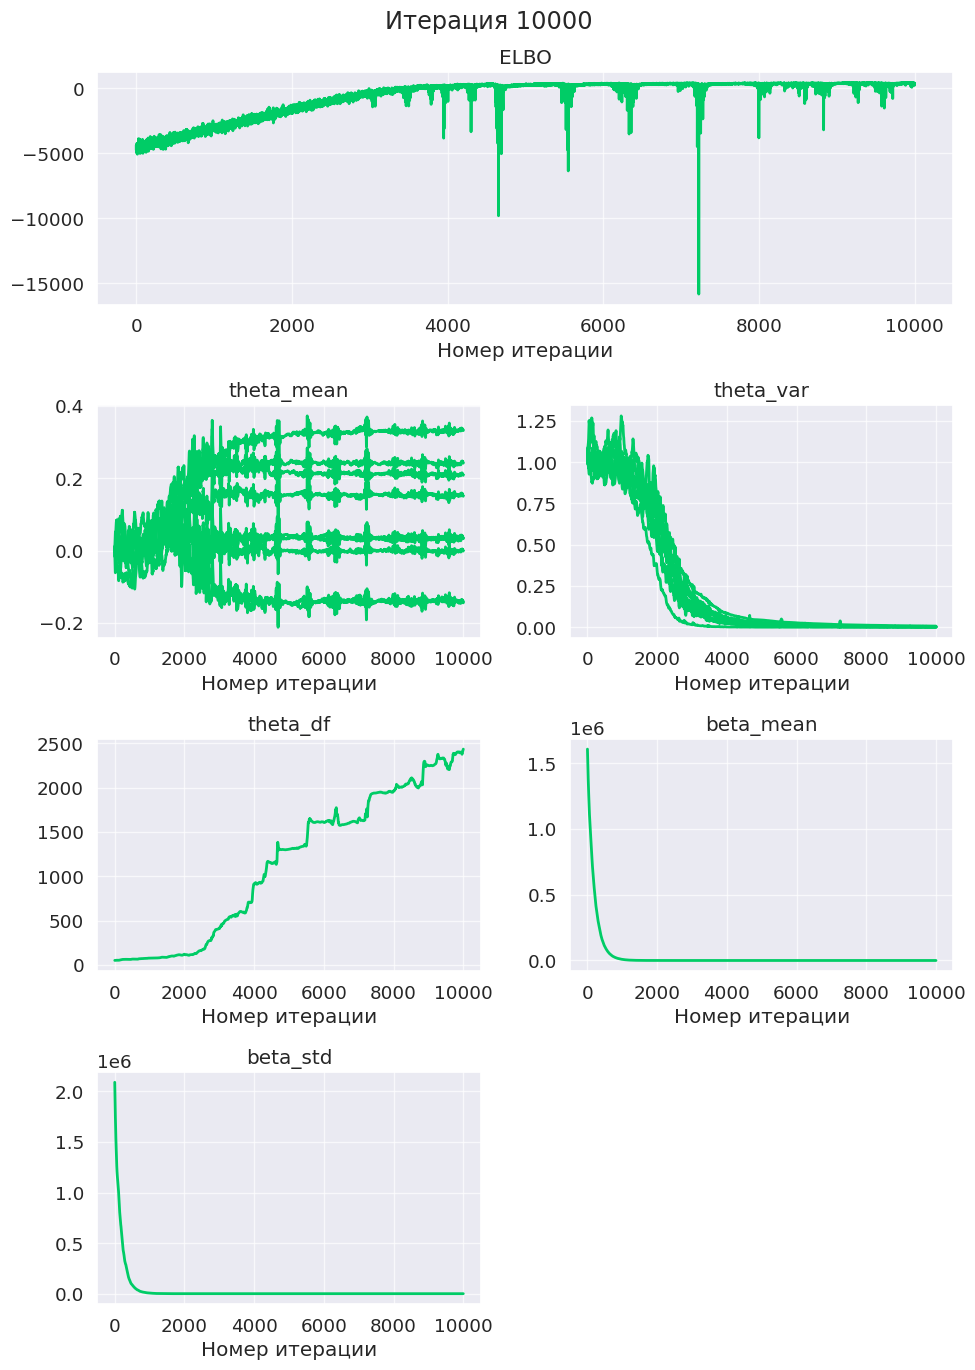

In [65]:
model = PyroBayesianRidgeStudent(X_train, Y_train, {"alpha":1, "beta_scale":0.25})
model.fit(n_iter=10001, lr=5e-3);

In [66]:
y_pred = model.predict(X_test)
y_pred = y_pred[0].detach().numpy()
y_pred = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).ravel()

In [67]:
results = get_metrics(y_test, y_pred, model_name="PyroBayesianRidge")
results

,Metric,PyroBayesianRidge
0,MSE,789125.19
1,MAE,660.59
2,MAPE (%),124.57


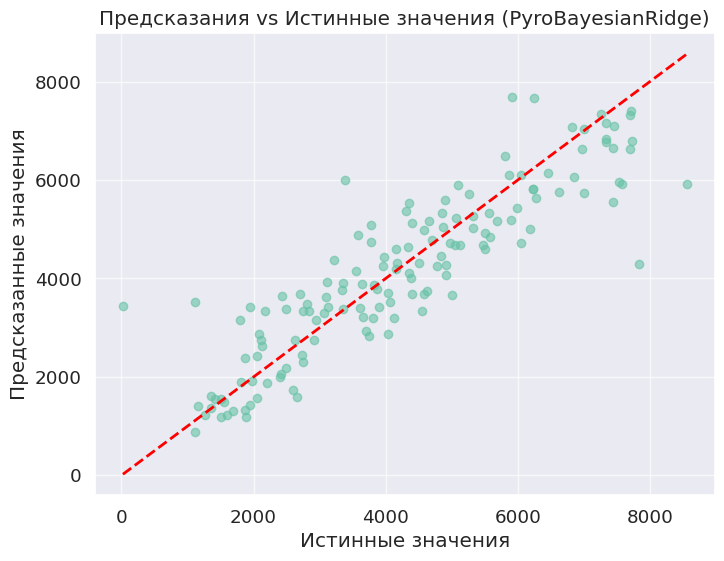

In [68]:
plot_test_pred(y_test, y_pred, "PyroBayesianRidge")

Как видим качество незначительно выросло. Кроме того наше распределение Стьюдента стало все сильнее напоминать нормальное, так количество степеней свободы стало больше 150.

**3.** Глядя на графики зависимости таргета от признаков можно предположить гетероскедастичность шума. Предложите способ, как можно адаптировать модель для работы в условиях гетероскедастичности, и реализуйте его.

Раз для каждого элемента наблюдается своя дисперсия, то разумено заменить одно $\beta$ на функцию от признаков, т.е. $\beta = \exp(X \cdot \phi)$ -- это сохранит положительность, а модель сможет сама настроить лучшие для себя параметры дисперсии.

In [69]:
class HeteroBayesianRidge(PyroBayesianRidge):
    def __init__(self, X, Y, priors):
        super().__init__(X, Y, priors)
        self.beta_prior_scale = priors.get("beta", 1.0)
        self.priors = priors

    def model(self):
        theta = pyro.sample(
            "theta",
            pyro_dist.MultivariateNormal(
                torch.zeros(self.d),
                covariance_matrix=self.priors["alpha"] * torch.eye(self.d),
            ),
        )
        phi = pyro.sample(
            "phi", pyro_dist.Normal(torch.zeros(self.d), torch.ones(self.d)).to_event(1)
        )

        with pyro.plate("data", self.n):
            mean = self.X @ theta
            log_var = self.X @ phi
            log_var = torch.clamp(log_var, -10, 10)  # стабилизация
            scale = torch.exp(0.5 * log_var)
            pyro.sample("Y", pyro_dist.Normal(mean, scale), obs=self.Y)

    def guide(self):
        theta_loc = pyro.param("theta_loc", torch.zeros(self.d))
        theta_cov = pyro.param(
            "theta_cov",
            self.alpha_prior * torch.eye(self.d),
            constraint=constraints.positive_definite,
        )
        theta_df = pyro.param(
            "theta_df", torch.tensor(50.0), constraint=constraints.positive
        )

        scale_tril = torch.linalg.cholesky(theta_cov)
        pyro.sample(
            "theta",
            pyro_dist.MultivariateStudentT(
                df=theta_df, loc=theta_loc, scale_tril=scale_tril
            ),
        )

        phi_loc = pyro.param(
            "phi_loc", torch.tensor([0.0] * self.d)
        )
        phi_scale = pyro.param(
            "phi_scale", torch.ones(self.d), constraint=constraints.positive
        )
        pyro.sample("phi", pyro_dist.Normal(phi_loc, phi_scale).to_event(1))

    def fit(self, n_iter=2000, lr=0.01):
        pyro.clear_param_store()
        optimizer = Adam({"lr": lr, "betas": (0.90, 0.999)})
        svi = SVI(self.model, self.guide, optimizer, loss=Trace_ELBO())

        losses = []
        trace = {
            "ELBO": [],
            "theta_mean": [],
            "theta_var": [],
            "theta_df": [],
            "phi_mean": [],
            "phi_std": [],
        }

        for step in range(n_iter):
            loss = svi.step()
            losses.append(loss)
            trace["ELBO"].append(-loss)

            # === Theta (оставляем как есть) ===
            theta_loc = pyro.param("theta_loc")
            theta_cov = pyro.param("theta_cov")
            theta_df = pyro.param("theta_df")
            trace["theta_mean"].append(theta_loc.detach().cpu().numpy().copy())
            trace["theta_var"].append(
                torch.diag(theta_cov).detach().cpu().numpy().copy()
            )
            trace["theta_df"].append(theta_df.item())

            phi_loc = pyro.param("phi_loc")
            phi_scale = pyro.param("phi_scale")

            trace["phi_mean"].append(phi_loc.detach().cpu().numpy().copy())
            trace["phi_std"].append(phi_scale.detach().cpu().numpy().copy())

            if visualize_or_not(step, n_iter):
                callback(trace, step, (10, 14))

        self.losses = losses
        self.trace = trace
        return losses
    def predict(self, X):
        X = torch.tensor(X, dtype=torch.float32)
        theta_loc = pyro.param("theta_loc")
        phi_loc = pyro.param("phi_loc")

        mean = X @ theta_loc
        log_var = X @ phi_loc
        log_var = torch.clamp(log_var, -10, 10)
        std = torch.exp(0.5 * log_var)

        return mean, std


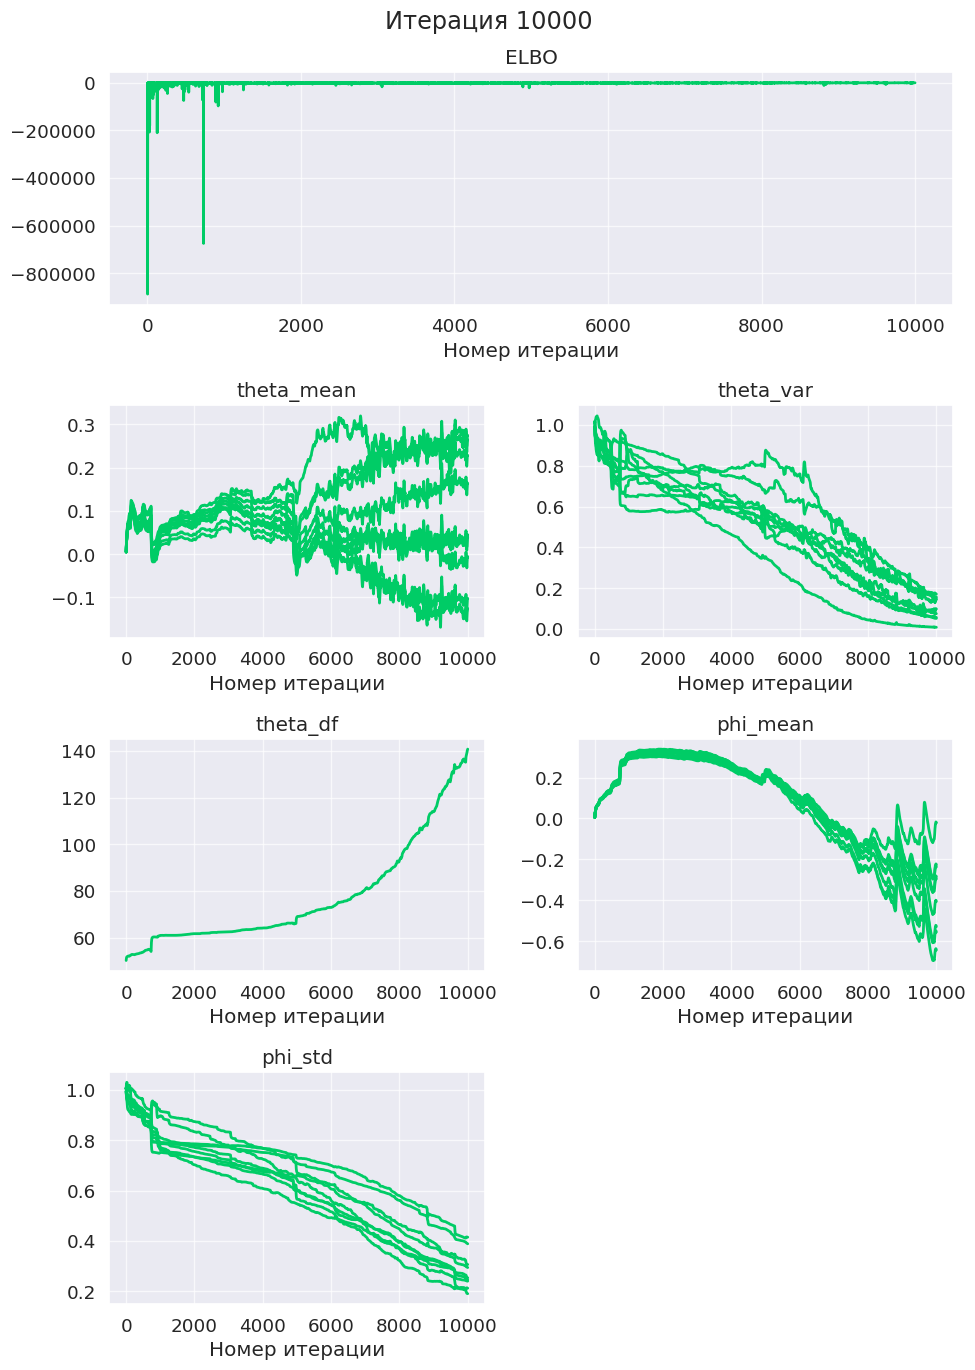

In [70]:
model = HeteroBayesianRidge(X_train, Y_train, {"alpha":1, "beta_scale":0.25})
model.fit(n_iter=10001, lr=5e-3);

In [71]:
y_pred = model.predict(X_test)
y_pred = y_pred[0].detach().numpy()
y_pred = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).ravel()


In [72]:
results = get_metrics(y_test, y_pred, model_name="PyroBayesianRidge")
results

,Metric,PyroBayesianRidge
0,MSE,836533.69
1,MAE,655.35
2,MAPE (%),141.70


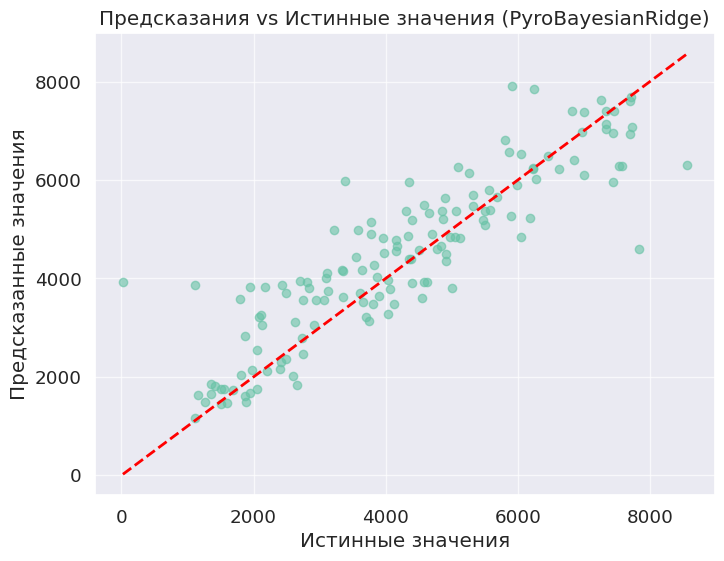

In [73]:
plot_test_pred(y_test, y_pred, "PyroBayesianRidge")

Как видим, качество незначительно, но ухудшилось.

Постройте графики оценки распределения дисперсии шума в зависимости от некоторых признаках. Удалось ли модели уловить зависимости?

In [74]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)

phi_loc = pyro.param("phi_loc")
phi_scale = pyro.param("phi_scale")

log_var = X_train_tensor @ phi_loc
log_var = torch.clamp(log_var, -10, 10)
std = torch.exp(0.5 * log_var)
var = std**2

mean_std = std.mean().item()
mean_var = var.mean().item()
print(mean_std, mean_var)

0.3301289975643158 0.11174093186855316


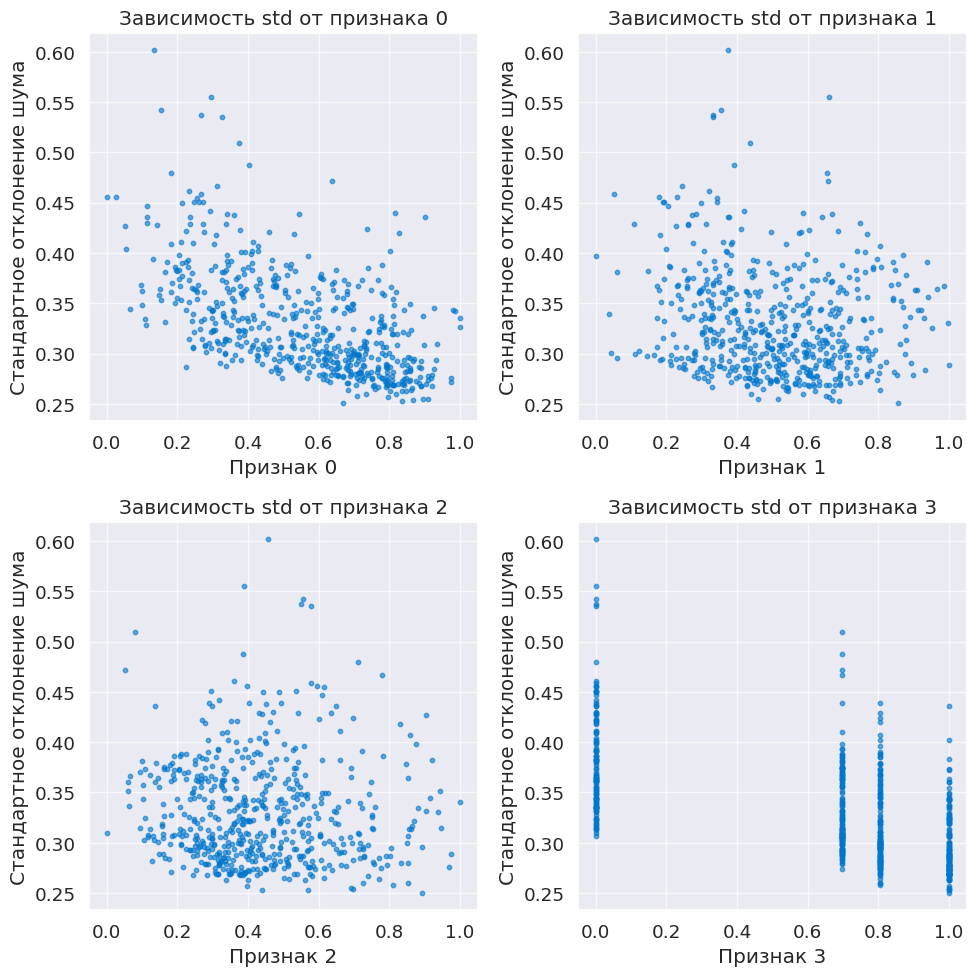

In [75]:
feature_indices = [0, 1, 2, 3]
n_features = len(feature_indices)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for idx, j in enumerate(feature_indices):
    ax = axes[idx]
    ax.scatter(X_train[:, j], std.detach().cpu().numpy(), alpha=0.6, s=10, color="#0077CC")
    ax.set_xlabel(f"Признак {j}")
    ax.set_ylabel("Стандартное отклонение шума")
    ax.set_title(f"Зависимость std от признака {j}")
    ax.grid(True)
    # ax.set_yscale("log")

for k in range(idx + 1, len(axes)):
    fig.delaxes(axes[k])

plt.tight_layout()
plt.show()

Как видим, теперь данные распределены равномерно, и их распределение не зависит от значения признака.

**4.** Обучите нейронную сеть для предсказания среднего и дисперсии таргета. Аналогично, визуализируйте оценки распределения дисперсии шума.

In [76]:
SimpleNN = nn.Sequential(
    nn.Linear(X_train.shape[1], 50),
    nn.ReLU(),
    nn.Linear(50, 20),
    nn.ReLU(),
    nn.Linear(20, 1)
)
loss = nn.MSELoss()
optimizer = torch.optim.Adam(SimpleNN.parameters(), lr=0.01)

In [77]:
def train_model(
    model,
    X_train,
    y_train,
    loss_fn,
    optimizer,
    epochs=100,
    batch_size=32,
    X_test=None,
    y_test=None,
    device=None,
    verbose=True,
    plot=True,
):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # Приведение данных к torch.Tensor
    def to_tensor(x):
        return x if isinstance(x, torch.Tensor) else torch.tensor(x, dtype=torch.float32)

    X_train, y_train = to_tensor(X_train), to_tensor(y_train)
    dataset = TensorDataset(X_train, y_train)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    X_test = to_tensor(X_test) if X_test is not None else None
    y_test = to_tensor(y_test) if y_test is not None else None

    train_loss_history = []
    test_loss_history = []

    model.train()
    for epoch in tqdm(range(1, epochs + 1), desc="Training", unit="epoch"):
        epoch_losses = []
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            preds = model(xb)
            loss = loss_fn(preds, yb)
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())

        # Train loss
        mean_train_loss = float(sum(epoch_losses) / len(epoch_losses))
        train_loss_history.append(mean_train_loss)

        # Test loss
        if X_test is not None and y_test is not None:
            model.eval()
            with torch.no_grad():
                preds_test = model(X_test.to(device))
                test_loss = loss_fn(preds_test, y_test.to(device)).item()
                test_loss_history.append(test_loss)
            model.train()
        else:
            test_loss_history.append(None)

        if verbose and (epoch == 1 or epoch % max(1, epochs // 10) == 0 or epoch == epochs):
            msg = f"Epoch {epoch}/{epochs} - train loss: {mean_train_loss:.6f}"
            if test_loss_history[-1] is not None:
                msg += f" - test loss: {test_loss_history[-1]:.6f}"
            print(msg)

    # Визуализация
    if plot:
        plt.figure(figsize=(8, 5))
        plt.plot(train_loss_history, label="Train Loss", color="#1f77b4", linewidth=2)
        if any(t is not None for t in test_loss_history):
            plt.plot(test_loss_history, label="Test Loss", color="#ff7f0e", linewidth=2)
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Train/Test Loss Curve")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    return {
        "train_loss": train_loss_history,
        "test_loss": test_loss_history,
    }


In [78]:
X_train_tensor = torch.tensor(X_train.values if hasattr(X_train, "values") else X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(Y_train.values if hasattr(Y_train, "values") else Y_train, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test.values if hasattr(X_test, "values") else X_test, dtype=torch.float32)
y_test_tensor  = torch.tensor(Y_test.values if hasattr(Y_test, "values") else Y_test, dtype=torch.float32)

Training:   0%|          | 0/50 [00:00<?, ?epoch/s]

/home/alexander/.venv/lib/python3.12/site-packages/torch/nn/modules/loss.py:616: UserWarning: Using a target size (torch.Size([32])) that is different to the input size (torch.Size([32, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/home/alexander/.venv/lib/python3.12/site-packages/torch/nn/modules/loss.py:616: UserWarning: Using a target size (torch.Size([145])) that is different to the input size (torch.Size([145, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


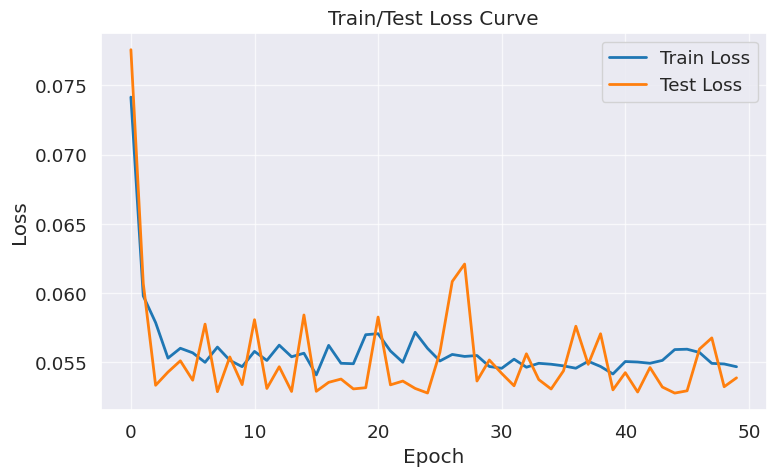

In [79]:
result = train_model(
    SimpleNN,
    X_train_tensor,
    y_train_tensor,
    loss,
    optimizer,
    epochs=50,
    batch_size=32,
    X_test=X_test_tensor,
    y_test=y_test_tensor,
    verbose=False,
    plot=True,
)

In [80]:
y_pred = SimpleNN(X_test_tensor).detach().numpy()
y_pred = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).ravel()

get_metrics(y_test, y_pred, model_name="SimpleNN")

,Metric,SimpleNN
0,MSE,3619281.00
1,MAE,1585.52
2,MAPE (%),194.71


In [81]:
print("{:<25} {:>15}".format("Параметр", "Количество"))
print("-" * 42)
total = 0
for name, param in SimpleNN.named_parameters():
    if param.requires_grad:
        count = param.numel()
        total += count
        print(f"{name:<25} {count:>15,}")
print("-" * 42)
print(f"{'Итого':<25} {total:>15,}")


Параметр                       Количество
------------------------------------------
0.weight                              450
0.bias                                 50
2.weight                            1,000
2.bias                                 20
4.weight                               20
4.bias                                  1
------------------------------------------
Итого                               1,541


Байесовский значительно выигрывает (MAE в 2 больше чем у SVI) у 3 слойного МЛП.

**Выводы:**

Мы проделали глубокий анализ байесовской линейной регрессии. 

Самое важное, мы получили результаты, сопоставимые с использование ARD регрегрессией лишь сделав предположение о природе распределения парметров модели, и значительно обогнали по качеству простой MLP.

Также добавление робастности положиетельно сказалось на качестве модели, так как в течении вывода количество степеней свободы стало слишком большим, а значит распределение Стьюдента выродилось в нормальное.

Мы учли дисперсию каждого элемента выборки, что позволило слегка снизить влияние гетероскедастичности, хоть и не подавило ее.

---
© 2025 команда <a href="https://thetahat.ru/">ThetaHat</a> для DS-потока